# Supplemental, find gamma for the chromatin

Code to trial find gamma for the chromatin. Checking the elbow curve consistently across different windows


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
from src.config import load_default_chrom_configs
from src.combined_chromatin_model import CombinedChromatinModel

config1, config2 = load_default_chrom_configs()

combined_model = CombinedChromatinModel(config1=config1, config2=config2)

chrom = 1
mnase_span = 30000, 30200

# Load window to deconvolve
combined_model.load_mnase_span(chrom, mnase_span)
combined_model.setup_deconv_model(copy_correct=False)

Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 199) to (16, 26, 20)
Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 199) to (15, 26, 20)
Loading copy correction N, Fr, B from output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr


Loading copy correction N, Fr, B from output/draft3_run/
	Base error (γ=0):	rn: 39.387693	sn: 2729.309833
	Error boundaries:
		Left:
			Relative (1.05 * e0): 41.3571
			Absolute (e0 + 1.00): 40.3877
			Chosen: 40.387693
		Right:
			Relative (1.40 * e0): 55.1428
			Absolute (e0 + 15.00): 54.3877
			Chosen: 55.142770
	Searching for left boundary gamma...
		Early stopping enabled (threshold: 1.0%)
		γ: 0.50005	rn: 47.4502	sn: 2.4635
		γ: 0.250075	rn: 45.9157	sn: 6.9376
		γ: 0.125087	rn: 44.3529	sn: 15.9231
		γ: 0.0625937	rn: 42.9688	sn: 31.5365
		γ: 0.0313469	rn: 42.0160	sn: 53.0057
		γ: 0.0157234	rn: 41.2204	sn: 89.9653
		γ: 0.00791172	rn: 40.6146	sn: 144.2718
		γ: 0.00400586	rn: 40.1896	sn: 219.5733
		γ: 0.00595879	rn: 40.4168	sn: 173.1042
		Early stopping: rn change (0.565%) < threshold (1.0%)
	Left boundary gamma found: 0.00595879
	Searching for right boundary gamma...
		γ: 0.502979	rn: 47.4583	sn: 2.4474
		γ: 0.75149	rn: 48.0723	sn: 1.4421
		γ: 0.875745	rn: 48.3263	sn: 1.1292
		Early

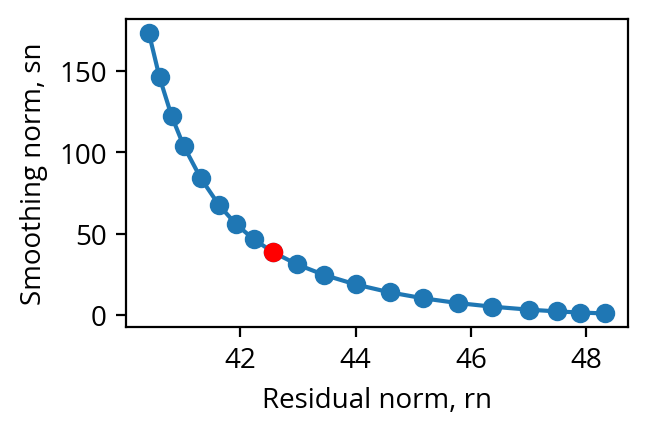

In [19]:
combined_model.deconvolve_find_optimal_gamma(kappa=1, eta=0, verbose=True)

In [32]:
combined_model.deconvolve(gamma=combined_model.find_gamma_chromatin.gamma_optimizer.optimal_gamma,
                         kappa=0.01, eta=0)

0/520 - 00:00:00.001
500/520 - 00:01:17.177
Completed - 00:01:19.326


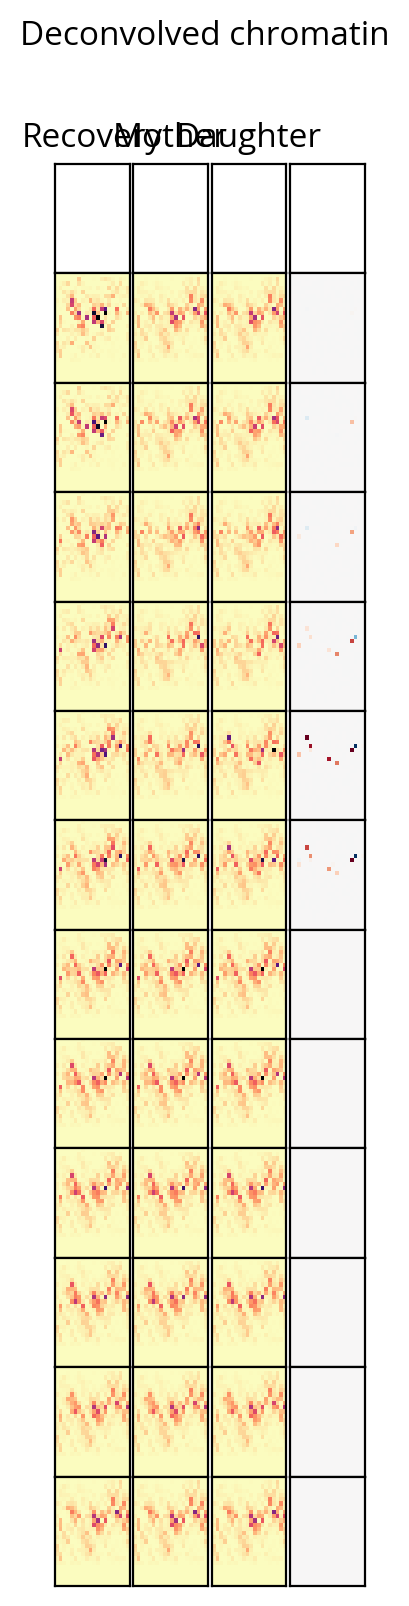

In [33]:
combined_model.plot_branches(figsize=(2, 9))

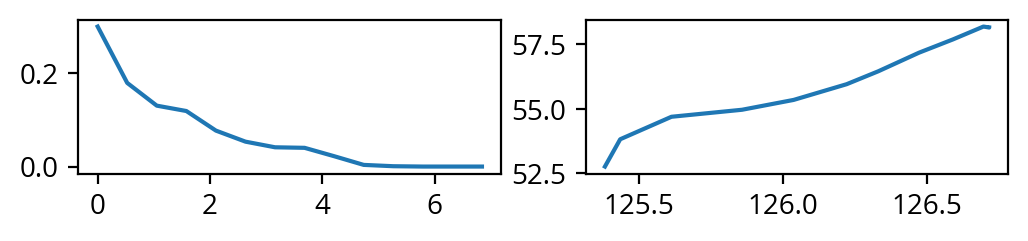

In [37]:
kappa = [0,0.52631,1.05263,1.57895,2.10526,2.63158,3.15789,3.68421,4.21053,4.73684,5.26316,5.78947,6.31579,6.84211]
diff = [0.300046, 0.179252, 0.130534, 0.119015, 0.077061, 0.053375, 0.041296, 0.040136, 0.022180, 0.003556, 0.000729, 0.000000, 0.000000, 0.000000]
rn = [ 125.383, 125.436, 125.614, 125.859, 126.038, 126.222, 126.332, 126.473, 126.591, 126.697, 126.713, 126.717, 126.717, 126.717]
sn = [52.7593,53.8182,54.6913,54.9634,55.3451,55.9548,56.4567,57.1768,57.6926,58.1919,58.1621,58.1540,58.1540,58.1543]

plt.figure(figsize=(6, 1))
plt.subplot(1, 2, 1)
plt.plot(kappa, diff)

plt.subplot(1, 2, 2)
plt.plot(rn, sn)

[0.026281007027701715,
 0.026281007027701715,
 0.026281007027701715,
 0.026281007027701715,
 0.026281007027701715,
 0.03746341219257206,
 0.03870561184388814,
 0.0487159884756994,
 0.0487159884756994,
 0.0487159884756994,
 0.0487159884756994,
 0.0487159884756994,
 0.0487159884756994]

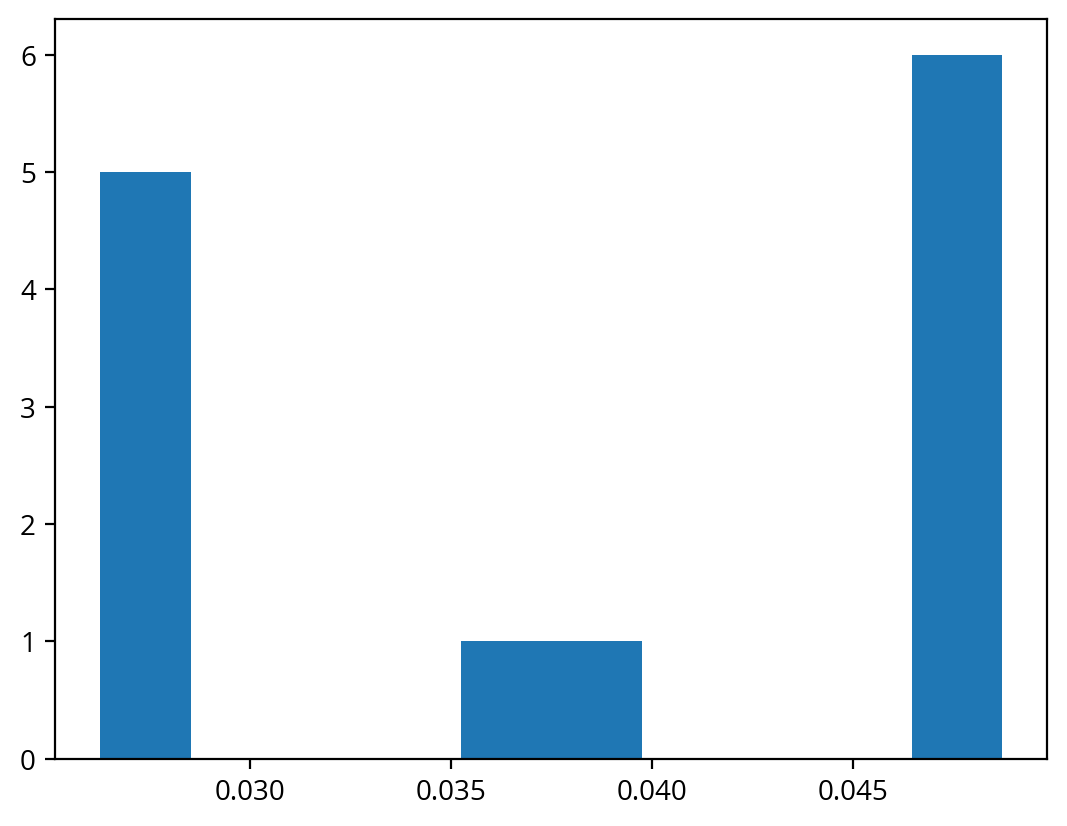

In [45]:
from glob import glob
gammas = []
for filepath in glob('output/draft3_run/chromatin_gamma_100/deconvolution_data/chr*/*.txt'):
    with open(filepath, 'r') as f:
        gamma = float(f.read())
        gammas.append(gamma)
        
plt.hist(gammas)
sorted(gammas)